# Detecting Synthetic Cannabinoids - CB1 Activity Prediction

**Problem.** Illegal labs evade drug bans by slightly modifying the molecular structure of
controlled synthetic cannabinoids. The new "formula" is not yet on any banned-substances list,
so it is hard to prosecute even though the compound is just as dangerous (e.g. the U420 case in
Ukraine, the HHCH gummies case in Japan).

These analogs remain dangerous because they still **bind and activate the CB1 cannabinoid
receptor**. So instead of matching a fixed banned list, we predict CB1 **activity directly from
molecular structure** (a QSAR / structure-activity approach). A model like this gives forensic
experts a fast triage signal and can speed up the legal scheduling of newly seized compounds.

**Task type.** Regression - we predict the continuous potency value `pChEMBL` (≈ -log10 of the
binding constant; higher = stronger), not a binary active/inactive label. This keeps the full
information about *how strongly* a compound acts, which is more informative than a hard yes/no.

**Data.** ChEMBL bioactivity records for the human CB1 receptor (target `CHEMBL218`):
SMILES structures + measured potency + publication year.

**Plan.**
1. Acquire & clean ChEMBL data.
2. **Temporal (chronological) split** - train on earlier compounds, test on later ones, to
   simulate detecting *newly appearing* analogs.
3. Baseline: Linear Regression on physico-chemical descriptors.
4. Improvement: Random Forest / XGBoost on Morgan fingerprints (structural fragments).
5. A custom domain metric: the cost of *dangerous misses*.
6. Feature importance & interpretation.

## 1. Imports

In [24]:
from chembl_webresource_client.new_client import new_client
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 2. Data acquisition

We query ChEMBL for all molecules tested against the CB1 receptor (`CHEMBL218`) that have a
usable potency value (`pchembl_value`). We keep binding/functional assay types (Ki, IC50, EC50,
Kd) and also pull `document_year` - the publication year - which we will use for the temporal
split.

In [25]:
import os
os.makedirs("data", exist_ok=True)

TARGET = "CHEMBL218"  # human Cannabinoid receptor 1
activity = new_client.activity
res = activity.filter(
    target_chembl_id=TARGET,
    pchembl_value__isnull=False,
    standard_type__in=["Ki", "IC50", "EC50", "Kd"],
).only([
    "molecule_chembl_id", "canonical_smiles",
    "standard_type", "standard_value", "pchembl_value",
    "document_chembl_id", "document_year",   # publication year -> temporal split
])

raw = pd.DataFrame(list(res))
raw.to_csv("data/cb1_raw.csv", index=False)

print("Raw shape:", raw.shape)
print("Missing document_year:", raw["document_year"].isnull().sum(),
      f"({raw['document_year'].isnull().mean()*100:.1f}%)")

Raw shape: (8589, 9)
Missing document_year: 109 (1.3%)


## 3. Missing-value analysis

Before cleaning we inspect what came back from the API. Two findings matter:
`canonical_smiles` has only a couple of missing rows (safe to drop), and many molecules appear in
**multiple** records (different assays / publications) - so we must deduplicate **per molecule**
before splitting, otherwise the same compound could leak into both train and test.

In [26]:
raw_csv = pd.read_csv("data/cb1_raw.csv")

print("Raw shape:", raw_csv.shape)
print("\nMissing values per column:")
print(raw_csv.isnull().sum())

# How many molecules have several measurements (duplicates)?
dup = raw_csv.groupby("molecule_chembl_id").size()
print("\nMolecules with >1 measurement:", (dup > 1).sum())
print("Max measurements for a single molecule:", dup.max())

Raw shape: (8589, 9)

Missing values per column:
canonical_smiles        2
document_chembl_id      0
document_year         109
molecule_chembl_id      0
pchembl_value           0
standard_type           0
standard_value          0
type                    0
value                   0
dtype: int64

Molecules with >1 measurement: 1595
Max measurements for a single molecule: 134


## 4. Cleaning & deduplication

We convert the numeric columns (they arrive as strings from the API), drop rows without a
structure / potency / year, and collapse each molecule to a single row:
- `pchembl_value` -> **mean** of its measurements (overall potency),
- `year` -> **minimum** publication year (when the molecule *first appeared* - the relevant date
  for "newly appearing" analogs).

In [27]:
# Numeric conversion (API returns strings)
raw["pchembl_value"] = pd.to_numeric(raw["pchembl_value"], errors="coerce")
raw["document_year"] = pd.to_numeric(raw["document_year"], errors="coerce")

# Drop rows without the required fields
raw = raw.dropna(subset=["canonical_smiles", "pchembl_value", "document_year"])

# Deduplicate per molecule: mean potency, earliest year
clean = raw.groupby(
    ["molecule_chembl_id", "canonical_smiles"], as_index=False
).agg(
    pchembl_value=("pchembl_value", "mean"),
    year=("document_year", "min"),
)
clean["year"] = clean["year"].astype(int)

# Binary label (kept for EDA plots and the classification experiment, NOT for regression)
clean["active"] = (clean["pchembl_value"] >= 6.5).astype(int)

print("Unique molecules:", len(clean))
print(clean["active"].value_counts())

Unique molecules: 5791
active
1    3490
0    2301
Name: count, dtype: int64


## 5. Exploratory data analysis

### Target distribution
The potency target is smoothly distributed (~4 to ~11, peak around 6-7), close to bell-shaped.
This is good for regression. The red line marks the 6.5 activity threshold - note it cuts right
through the dense centre, which is exactly why a hard active/inactive split would throw away
information that regression keeps.

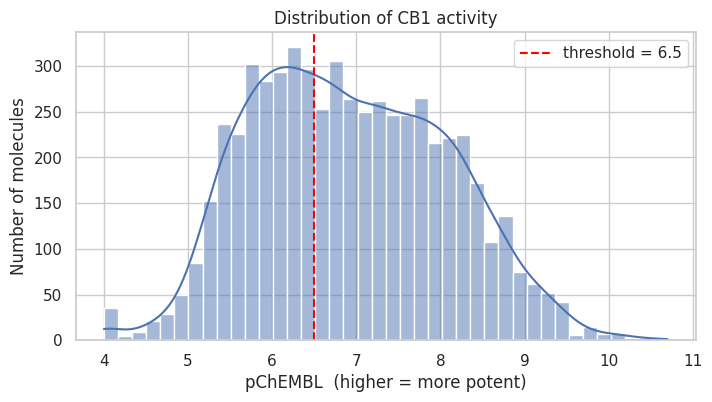

In [28]:
plt.figure(figsize=(8, 4))
sns.histplot(clean["pchembl_value"], bins=40, kde=True)
plt.axvline(6.5, color="red", linestyle="--", label="threshold = 6.5")
plt.xlabel("pChEMBL  (higher = more potent)")
plt.ylabel("Number of molecules")
plt.title("Distribution of CB1 activity")
plt.legend()
plt.show()

### Class balance
If we *were* to binarise at 6.5, the classes are reasonably balanced (~41% / 59%), so no
resampling tricks would be needed.

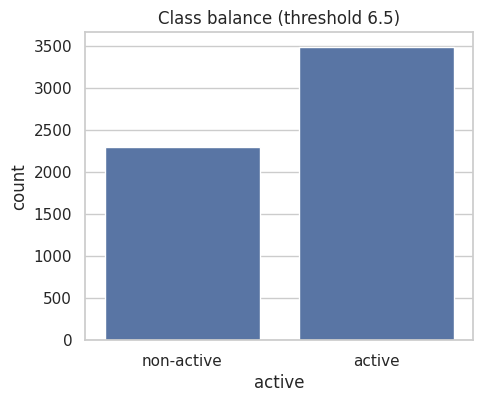

In [29]:
plt.figure(figsize=(5, 4))
sns.countplot(x="active", data=clean)
plt.xticks([0, 1], ["non-active", "active"])
plt.title("Class balance (threshold 6.5)")
plt.show()

## 6. Temporal (chronological) split

**Why not a random split?** New analogs are created *over time*, deliberately, to evade bans.
The honest question is therefore: *trained on compounds known up to a point in time, can the
model recognise compounds that appeared later?* A random split would not test this; a temporal
split does, and it simulates the real deployment scenario.

**Caveat (stated honestly):** ChEMBL has no "first synthesised illicitly" date, so we use
publication year as a proxy. The split therefore tests generalisation to *structurally newer*
compounds - a reasonable stand-in for novel evasion analogs, not a literal "pre-ban vs post-ban".

We scan a few cutoff years and pick one giving ~15-20% of molecules to the test set.

In [30]:
for cutoff in [2015, 2016, 2017, 2018, 2019]:
    n_train = (clean["year"] <= cutoff).sum()
    n_test = (clean["year"] > cutoff).sum()
    pct = n_test / len(clean) * 100
    print(f"cutoff {cutoff}: train={n_train}, test={n_test} ({pct:.1f}%)")

cutoff 2015: train=3673, test=2118 (36.6%)
cutoff 2016: train=4280, test=1511 (26.1%)
cutoff 2017: train=4798, test=993 (17.1%)
cutoff 2018: train=4954, test=837 (14.5%)
cutoff 2019: train=5180, test=611 (10.6%)


We choose **cutoff = 2017** (train ≤ 2017, test ≥ 2018): ~83% / 17%, a clean ~80/20 split with
enough test molecules for stable metrics. The mean potency barely shifts between train and test
(≈6.95 -> ≈6.80), so the task is feasible; the test set is only slightly more spread out, which is
expected as chemistry explores a wider space over time.

In [31]:
CUTOFF = 2017
train_df = clean[clean["year"] <= CUTOFF].copy()
test_df  = clean[clean["year"] >  CUTOFF].copy()

print(f"Train: {len(train_df)} molecules (years {train_df['year'].min()}-{train_df['year'].max()})")
print(f"Test:  {len(test_df)} molecules (years {test_df['year'].min()}-{test_df['year'].max()})")
print("\npChEMBL (train):"); print(train_df["pchembl_value"].describe().round(2))
print("\npChEMBL (test):");  print(test_df["pchembl_value"].describe().round(2))

train_df.to_csv("data/train.csv", index=False)
test_df.to_csv("data/test.csv", index=False)
print("\nSaved data/train.csv and data/test.csv")

Train: 4798 molecules (years 1996-2017)
Test:  993 molecules (years 2018-2025)

pChEMBL (train):
count    4798.00
mean        6.95
std         1.11
min         4.00
25%         6.05
50%         6.88
75%         7.80
max        10.18
Name: pchembl_value, dtype: float64

pChEMBL (test):
count    993.00
mean       6.80
std        1.33
min        4.00
25%        5.88
50%        6.64
75%        7.78
max       10.70
Name: pchembl_value, dtype: float64

Saved data/train.csv and data/test.csv


## 7. Featurization - molecular descriptors

A model needs numbers, not SMILES text. The simplest, **interpretable** featurization is a set of
physico-chemical descriptors computed directly from the structure by RDKit (mass, lipophilicity,
ring counts, etc.). We compute them **separately** for train and test - no information from the
test set touches the train preparation.

In [32]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski

def compute_descriptors(df):
    """Compute physico-chemical descriptors from SMILES."""
    rows = []
    for smiles in df["canonical_smiles"]:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            rows.append(None)
            continue
        rows.append({
            "mol_weight":      Descriptors.MolWt(mol),            # molecular weight
            "logp":            Crippen.MolLogP(mol),              # lipophilicity
            "tpsa":            Descriptors.TPSA(mol),             # topological polar surface area
            "h_donors":        Lipinski.NumHDonors(mol),          # H-bond donors
            "h_acceptors":     Lipinski.NumHAcceptors(mol),       # H-bond acceptors
            "rotatable_bonds": Descriptors.NumRotatableBonds(mol),# rotatable bonds
            "aromatic_rings":  Lipinski.NumAromaticRings(mol),    # aromatic rings
            "num_rings":       Descriptors.RingCount(mol),        # all rings
            "num_heavy_atoms": Descriptors.HeavyAtomCount(mol),   # heavy (non-H) atoms
            "fraction_csp3":   Descriptors.FractionCSP3(mol),     # fraction of sp3 carbons
        })
    desc = pd.DataFrame(rows, index=df.index)
    desc["pchembl_value"] = df["pchembl_value"].values
    desc["year"] = df["year"].values
    return desc.dropna()

train_feat = compute_descriptors(train_df)
test_feat  = compute_descriptors(test_df)

print("Train features:", train_feat.shape)
print("Test features:", test_feat.shape)
train_feat.head()

Train features: (4798, 12)
Test features: (993, 12)


,mol_weight,logp,tpsa,h_donors,h_acceptors,rotatable_bonds,aromatic_rings,num_rings,num_heavy_atoms,fraction_csp3,pchembl_value,year
0,355.48200,6.02620,78.22,1,3,6,1,3,26,0.619048,7.72,2007
1,495.98300,4.24120,77.37,1,4,5,2,4,33,0.363636,6.55,2010
2,477.99300,3.39760,77.37,1,3,4,2,4,32,0.363636,8.56,2010
3,403.35300,5.02710,23.55,0,2,4,2,4,27,0.409091,6.54,2010
4,525.36663,4.15488,83.18,1,5,5,3,4,31,0.260870,8.47,2009


### Which descriptors relate to activity?
Correlations are computed **only on the train set**. They are all weak (|r| ≤ ~0.2), which is an
early warning: no single physical property predicts potency on its own. The signs are chemically
sensible though - lipophilicity, aromatic rings and size correlate positively (cannabinoids are
large, lipophilic molecules), while `fraction_csp3` (saturation) correlates negatively.

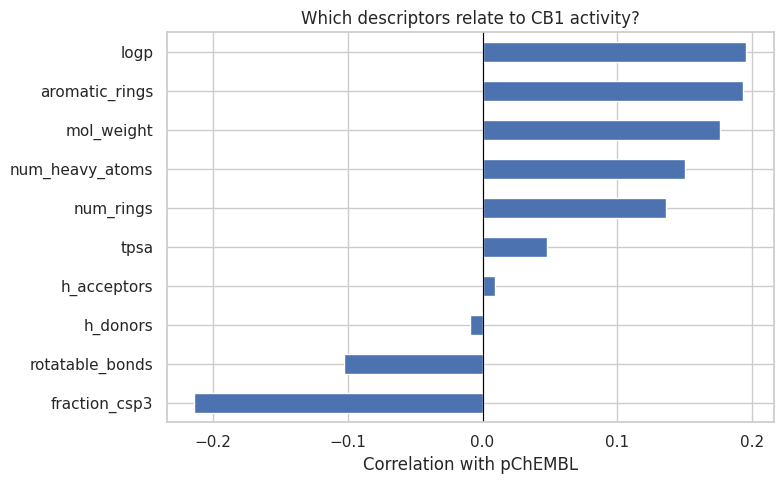

logp               0.196
aromatic_rings     0.194
mol_weight         0.176
num_heavy_atoms    0.150
num_rings          0.136
tpsa               0.048
h_acceptors        0.009
h_donors          -0.009
rotatable_bonds   -0.103
fraction_csp3     -0.214
Name: pchembl_value, dtype: float64


In [33]:
feature_cols = ["mol_weight", "logp", "tpsa", "h_donors", "h_acceptors",
                "rotatable_bonds", "aromatic_rings", "num_rings",
                "num_heavy_atoms", "fraction_csp3"]

corr = train_feat[feature_cols + ["pchembl_value"]].corr()["pchembl_value"].drop("pchembl_value")

plt.figure(figsize=(8, 5))
corr.sort_values().plot(kind="barh")
plt.xlabel("Correlation with pChEMBL")
plt.title("Which descriptors relate to CB1 activity?")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()
print(corr.sort_values(ascending=False).round(3))

## 8. Baseline model - Linear Regression on descriptors

Features are standardised (the scaler is fit on **train only**, then applied to both - no leakage).
The baseline is intentionally simple and interpretable.

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X_train = train_feat[feature_cols]; y_train = train_feat["pchembl_value"]
X_test  = test_feat[feature_cols];  y_test  = test_feat["pchembl_value"]

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

lr = LinearRegression().fit(X_train_s, y_train)
pred = lr.predict(X_test_s)

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae  = mean_absolute_error(y_test, pred)
r2   = r2_score(y_test, pred)

print("=== Linear Regression (descriptors) ===")
print(f"RMSE: {rmse:.3f}\nMAE:  {mae:.3f}\nR2:   {r2:.3f}")
print("R2 train:", round(r2_score(y_train, lr.predict(X_train_s)), 3))
print("R2 test: ", round(r2, 3))

=== Linear Regression (descriptors) ===
RMSE: 1.272
MAE:  1.012
R2:   0.080
R2 train: 0.134
R2 test:  0.08


**Reading the baseline.** R² ≈ 0.08 is weak, and train R² is also low - this is *underfitting*,
not overfitting: the descriptors simply do not contain enough information. Potency depends on the
precise 3D arrangement of atoms, which generic properties cannot capture. This is the expected,
honest baseline and it motivates the structural features used next.

## 9. A domain-specific metric: cost of *dangerous misses*

Standard RMSE/R² treat all errors equally. But in drug detection they are not equal: predicting a
genuinely active compound (pChEMBL ≥ 6.5) as *inactive* (a **dangerous miss**) is far worse than
the opposite - a missed dangerous compound vs. a needless extra check. This custom metric (a) counts
how many active compounds fall below the threshold, and (b) computes a danger-weighted RMSE that
penalises those misses `PENALTY`× more. The penalty encodes our domain cost choice.

In [35]:
THRESHOLD = 6.5
PENALTY = 5.0   # how much worse a dangerous miss is than an ordinary error (our choice)

def danger_aware_error(y_true, y_pred, threshold=THRESHOLD, penalty=PENALTY):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    base = (y_true - y_pred) ** 2
    dangerous_miss = (y_true >= threshold) & (y_pred < threshold)
    weighted = np.where(dangerous_miss, base * penalty, base)
    return np.sqrt(weighted.mean())

def report_misses(y_true, y_pred, name):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    miss = (y_true >= THRESHOLD) & (y_pred < THRESHOLD)
    n_active = (y_true >= THRESHOLD).sum()
    print(f"[{name}] dangerous misses: {miss.sum()}/{n_active} "
          f"({miss.sum()/n_active*100:.1f}%) | danger-aware RMSE: "
          f"{danger_aware_error(y_true, y_pred):.3f}")
    return miss.sum() / n_active * 100

miss_lr = report_misses(y_test, pred, "Linear")

[Linear] dangerous misses: 128/534 (24.0%) | danger-aware RMSE: 1.780


## 10. Improvement - Morgan fingerprints + Random Forest

Morgan fingerprints (ECFP) encode the molecule as a 2048-bit vector of structural fragments: each
bit marks whether a particular atom-neighbourhood pattern is present. Unlike generic descriptors,
this captures *specific structure*. The vector is sparse (~50 active bits), which tree models
handle well.

In [36]:
from rdkit.Chem import rdFingerprintGenerator

_morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def compute_fingerprints(df):
    """Binary Morgan fingerprints (presence/absence of fragments)."""
    fps, valid_idx = [], []
    for idx, smiles in zip(df.index, df["canonical_smiles"]):
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            continue
        fps.append(_morgan_gen.GetFingerprintAsNumPy(mol).astype(np.int8))
        valid_idx.append(idx)
    return np.array(fps), df.loc[valid_idx, "pchembl_value"].values

X_train_fp, y_train_fp = compute_fingerprints(train_df)
X_test_fp,  y_test_fp  = compute_fingerprints(test_df)
print("Train fingerprints:", X_train_fp.shape, "| Test:", X_test_fp.shape)
print("Avg. active bits per molecule:", X_train_fp.sum(axis=1).mean().round(1))

Train fingerprints: (4798, 2048) | Test: (993, 2048)
Avg. active bits per molecule: 52.6


In [37]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)
rf.fit(X_train_fp, y_train_fp)
pred_rf = rf.predict(X_test_fp)

print("=== Random Forest (fingerprints) ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_fp, pred_rf)):.3f}")
print(f"MAE:  {mean_absolute_error(y_test_fp, pred_rf):.3f}")
print(f"R2:   {r2_score(y_test_fp, pred_rf):.3f}")
miss_rf = report_misses(y_test_fp, pred_rf, "RandomForest")

=== Random Forest (fingerprints) ===
RMSE: 1.060
MAE:  0.775
R2:   0.362
[RandomForest] dangerous misses: 151/534 (28.3%) | danger-aware RMSE: 1.703


## 11. Count fingerprints + XGBoost

Two refinements: (1) **count** fingerprints store how *many* times each fragment occurs, not just
presence/absence - more information for the model; (2) **XGBoost** builds trees sequentially, each
correcting the previous one, combining fragments more finely than independent Random-Forest trees.

In [38]:
_morgan_gen_count = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def compute_count_fingerprints(df):
    fps, valid_idx = [], []
    for idx, smiles in zip(df.index, df["canonical_smiles"]):
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            continue
        fps.append(_morgan_gen_count.GetCountFingerprintAsNumPy(mol).astype(np.int16))
        valid_idx.append(idx)
    return np.array(fps), df.loc[valid_idx, "pchembl_value"].values

X_train_cfp, y_train_cfp = compute_count_fingerprints(train_df)
X_test_cfp,  y_test_cfp  = compute_count_fingerprints(test_df)
print("Train count-fp:", X_train_cfp.shape, "| max count in a bit:", X_train_cfp.max())

Train count-fp: (4798, 2048) | max count in a bit: 64


In [39]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=826, learning_rate=0.031, max_depth=7,
                   subsample=0.586, colsample_bytree=0.771, min_child_weight=10,
                   reg_alpha=0.00058, reg_lambda=0.0256, n_jobs=-1, random_state=42)
xgb.fit(X_train_cfp, y_train_cfp)
pred_xgb = xgb.predict(X_test_cfp)

print("=== XGBoost (count fingerprints) ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_cfp, pred_xgb)):.3f}")
print(f"MAE:  {mean_absolute_error(y_test_cfp, pred_xgb):.3f}")
print(f"R2:   {r2_score(y_test_cfp, pred_xgb):.3f}")
miss_xgb = report_misses(y_test_cfp, pred_xgb, "XGBoost")

=== XGBoost (count fingerprints) ===
RMSE: 1.027
MAE:  0.742
R2:   0.401
[XGBoost] dangerous misses: 164/534 (30.7%) | danger-aware RMSE: 1.669


**Result.** Fingerprint models lift R² from ~0.08 to ~0.40 - strong evidence that *specific
structure* carries far more signal than generic properties. Note an interesting effect: the more
accurate models have slightly *more* dangerous misses. This is not a bug - the weak linear model
hugged the mean (~6.9) so few predictions ever crossed below the threshold, whereas the accurate
models spread predictions wider and cross the 6.5 boundary more often. RMSE/R² and the
threshold-based miss rate measure different things; the right fix for misses is shifting the
decision threshold, not a stronger model.

## 12. Hypothesis check - does a classifier reduce dangerous misses?

A regressor minimises squared error (it ignores the threshold); a classifier minimises the
decision error at the boundary. So one might expect a classifier to make fewer dangerous misses.
We test this with Logistic Regression on the **same descriptors and the same temporal split**,
using `class_weight="balanced"` to encode the higher cost of missing an active compound.

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_train_clf = (y_train >= THRESHOLD).astype(int)
y_test_clf  = (y_test  >= THRESHOLD).astype(int)

clf = LogisticRegression(max_iter=1000, class_weight="balanced").fit(X_train_s, y_train_clf)
pred_clf  = clf.predict(X_test_s)
proba_clf = clf.predict_proba(X_test_s)[:, 1]

print("=== Logistic Regression (active/inactive) ===")
print(classification_report(y_test_clf, pred_clf, target_names=["inactive", "active"], digits=3))
print("ROC-AUC:", round(roc_auc_score(y_test_clf, proba_clf), 3))

cm = confusion_matrix(y_test_clf, pred_clf)
fn = cm[1, 0]; n_active = cm[1, 0] + cm[1, 1]
print(f"Dangerous misses (false negatives): {fn}/{n_active} ({fn/n_active*100:.1f}%)")

=== Logistic Regression (active/inactive) ===
              precision    recall  f1-score   support

    inactive      0.595     0.793     0.680       459
      active      0.751     0.536     0.625       534

    accuracy                          0.655       993
   macro avg      0.673     0.664     0.652       993
weighted avg      0.679     0.655     0.650       993

ROC-AUC: 0.658
Dangerous misses (false negatives): 248/534 (46.4%)


**Hypothesis rejected.** The classifier actually does *worse* on dangerous misses (~46%).
Logistic Regression is still a *linear* model on the same weak descriptors, so it shares the
baseline's limitation. The low ROC-AUC (~0.66) confirms it barely separates the classes. Takeaway:
the problem is not the model *type* (regression vs classification) but the *informativeness of the
features*. The real improvement comes from descriptors -> structural fingerprints, not from
switching to a classifier.

## 13. Feature importance & interpretation

### Descriptor importance (interpretable)
Permutation importance for the linear model - here features have names, so we can read it in plain
language. The top features are molecular size, flexibility and lipophilicity. This is chemically
sensible: CB1 has a large hydrophobic binding pocket, so larger, more lipophilic molecules bind
more strongly - matching the known pharmacology of synthetic cannabinoids. The importances are all
small, again confirming that no single property determines activity.

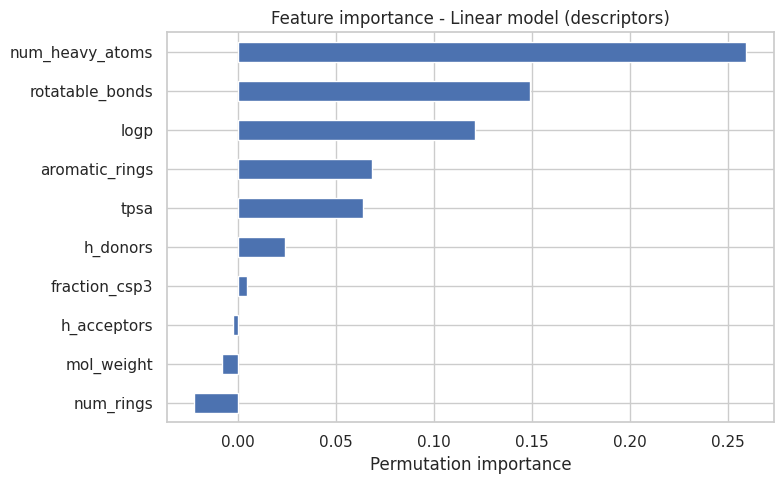

num_heavy_atoms    0.2594
rotatable_bonds    0.1492
logp               0.1210
aromatic_rings     0.0687
tpsa               0.0637
h_donors           0.0244
fraction_csp3      0.0050
h_acceptors       -0.0023
mol_weight        -0.0079
num_rings         -0.0221
dtype: float64


In [41]:
from sklearn.inspection import permutation_importance

result_lr = permutation_importance(lr, X_test_s, y_test, n_repeats=10,
                                   random_state=42, n_jobs=-1)
imp = pd.Series(result_lr.importances_mean, index=feature_cols).sort_values()

plt.figure(figsize=(8, 5))
imp.plot(kind="barh")
plt.xlabel("Permutation importance")
plt.title("Feature importance - Linear model (descriptors)")
plt.tight_layout()
plt.show()
print(imp.sort_values(ascending=False).round(4))

### Fingerprint-bit importance (XGBoost)
For completeness, the most important fingerprint bits of the best model. Individual bit IDs are not
human-readable on their own (each maps to a structural fragment), so this complements - rather than
replaces - the interpretable descriptor analysis above.

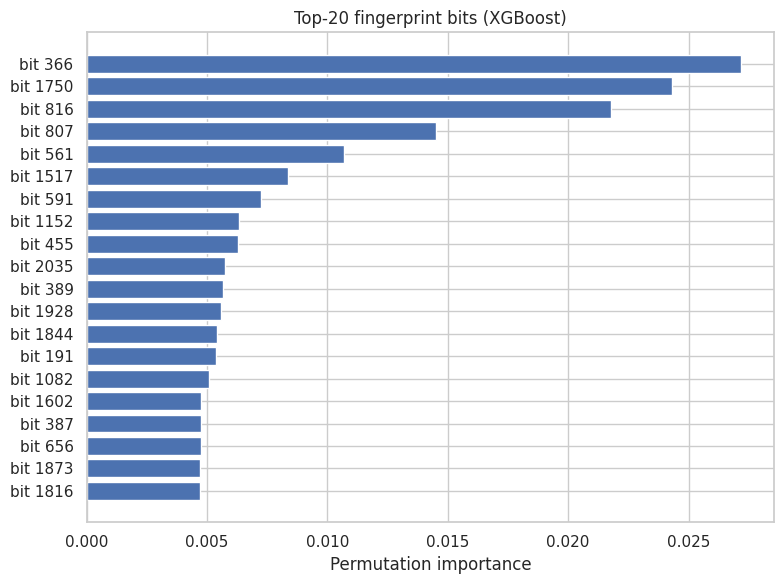

In [42]:
result_xgb = permutation_importance(xgb, X_test_cfp, y_test_cfp, n_repeats=5,
                                    random_state=42, n_jobs=-1)
top_idx = result_xgb.importances_mean.argsort()[::-1][:20]

plt.figure(figsize=(8, 6))
plt.barh([f"bit {i}" for i in top_idx][::-1],
         result_xgb.importances_mean[top_idx][::-1])
plt.xlabel("Permutation importance")
plt.title("Top-20 fingerprint bits (XGBoost)")
plt.tight_layout()
plt.show()

## 14. Model comparison summary

In [43]:
summary = pd.DataFrame([
    {"model": "Linear Regression",  "features": "descriptors",      "task": "regression",
     "R2": r2_score(y_test, pred),
     "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
     "dangerous_miss_%": miss_lr},
    {"model": "Random Forest",      "features": "binary fingerprints", "task": "regression",
     "R2": r2_score(y_test_fp, pred_rf),
     "RMSE": np.sqrt(mean_squared_error(y_test_fp, pred_rf)),
     "dangerous_miss_%": miss_rf},
    {"model": "XGBoost",            "features": "count fingerprints",  "task": "regression",
     "R2": r2_score(y_test_cfp, pred_xgb),
     "RMSE": np.sqrt(mean_squared_error(y_test_cfp, pred_xgb)),
     "dangerous_miss_%": miss_xgb},
]).round(3)
summary

,model,features,task,R2,RMSE,dangerous_miss_%
0,Linear Regression,descriptors,regression,0.080,1.272,23.970
1,Random Forest,binary fingerprints,regression,0.362,1.060,28.277
2,XGBoost,count fingerprints,regression,0.401,1.027,30.712


## 15. Tuning the decision threshold

The dangerous-miss rate depends on *where* we draw the active/inactive line on the model's
prediction, not only on model accuracy. Lowering the decision threshold flags more borderline
compounds as active, reducing dangerous misses (false negatives, FN) at the cost of more false
alarms (false positives, FP). The true activity label stays at 6.5; only the decision cut moves.

In [44]:
THRESHOLD = 6.5

print(f"{'Threshold':>6} | {'FN':>14} | {'FP':>18}")
print("-" * 46)

y_true = np.asarray(y_test_cfp)
pred   = np.asarray(pred_xgb)
truly_active   = y_true >= THRESHOLD
truly_inactive = ~truly_active

for decision in [6.5, 6.4, 6.3, 6.2, 6.1, 6.0]:
    pred_active = pred >= decision
    fn = (truly_active & ~pred_active).sum()
    fp = (truly_inactive & pred_active).sum()
    n_active = truly_active.sum()
    n_inactive = truly_inactive.sum()
    print(f"{decision:>6.1f} | {fn:>5}/{n_active}  ({fn/n_active*100:>4.1f}%) | "
          f"{fp:>5}/{n_inactive}  ({fp/n_inactive*100:>4.1f}%)")

Threshold |             FN |                 FP
----------------------------------------------
   6.5 |   164/534  (30.7%) |   111/459  (24.2%)
   6.4 |   139/534  (26.0%) |   157/459  (34.2%)
   6.3 |   110/534  (20.6%) |   209/459  (45.5%)
   6.2 |    86/534  (16.1%) |   266/459  (58.0%)
   6.1 |    56/534  (10.5%) |   316/459  (68.8%)
   6.0 |    35/534  ( 6.6%) |   359/459  (78.2%)


**Reading the trade-off.** Lowering the cut from 6.5 to 6.0 drops dangerous misses sharply
(about 31% down to 6%) but false alarms climb from about 24% to 78%. A threshold around
6.2-6.3 is a sensible balance for this use case: catching more dangerous compounds is worth some
extra checks, since a missed active compound is costlier than a needless review. Key point: the
best model and the best operating point are different choices - the model is fixed, the threshold
is calibrated to the cost of errors.

## 16. Hypothesis check - do fingerprints + descriptors help together?

Morgan fingerprints encode local structure; physico-chemical descriptors encode global properties.
They might be complementary, so we concatenate both feature sets and retrain XGBoost (tuned params).

In [45]:

desc_train = train_feat[feature_cols].values
desc_test  = test_feat[feature_cols].values

X_train_combo = np.hstack([X_train_cfp, desc_train])
X_test_combo  = np.hstack([X_test_cfp,  desc_test])

print("Combined features:", X_train_combo.shape, "(2048 fp + 10 desc = 2058)")

from xgboost import XGBRegressor
xgb_combo = XGBRegressor(
    n_estimators=826, learning_rate=0.031, max_depth=7,
    subsample=0.586, colsample_bytree=0.771, min_child_weight=10,
    reg_alpha=0.00058, reg_lambda=0.0256,
    n_jobs=-1, random_state=42,
)
xgb_combo.fit(X_train_combo, y_train_cfp)
pred_combo = xgb_combo.predict(X_test_combo)

print("\n=== XGBoost (fingerprints + descriptors) ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_cfp, pred_combo)):.3f}")
print(f"MAE:  {mean_absolute_error(y_test_cfp, pred_combo):.3f}")
print(f"R2:   {r2_score(y_test_cfp, pred_combo):.3f}")
miss_combo = report_misses(y_test_cfp, pred_combo, "XGBoost+desc")

Combined features: (4798, 2058) (2048 fp + 10 desc = 2058)

=== XGBoost (fingerprints + descriptors) ===
RMSE: 1.047
MAE:  0.770
R2:   0.377
[XGBoost+desc] dangerous misses: 168/534 (31.5%) | danger-aware RMSE: 1.734


**Hypothesis rejected.** Combining the two feature sets does not improve the model (R2 stays
about 0.38, essentially unchanged or slightly worse). The reason: physico-chemical properties are
already implicitly encoded in the structural fragments (mass is the sum of atoms, ring counts are
captured by ring fragments, etc.), so the 10 extra descriptors are redundant and add only noise.
This confirms that Morgan fingerprints are an information-rich representation on their own.

## 17. Conclusions & future work

**What we found**
- A temporal split makes the task realistic: predict activity for compounds appearing *later* in
  time, simulating novel evasion analogs.
- Generic physico-chemical descriptors are weak (R2 about 0.08, underfitting): activity depends on
  fine structure, not bulk properties.
- Structural Morgan fingerprints + gradient boosting lift R2 to about 0.41 (after Optuna tuning):
  the main baseline to improvement result.
- A custom *dangerous-miss* metric exposes a practical issue that RMSE/R2 hide, and shows that the
  most accurate model is not automatically the safest at a fixed decision threshold.
- Several hypotheses were tested and rejected: a classifier did not beat threshold-on-regression
  for misses; rescaling the target does not change R2; and adding descriptors to fingerprints does
  not help (properties are already encoded in the fragments). The bottleneck is feature
  informativeness, not model type.
- A separate graph neural network (see 03_gnn.ipynb) reached only R2 about 0.22, below XGBoost,
  because GNNs need far more data than ~4800 molecules.

**Production model choice.** For the MLOps pipeline we deploy **XGBoost on count fingerprints**
(Optuna-tuned): the best performer that is also lightweight and reliably reproducible on another
machine.

**Future work.** A message-passing GNN (e.g. Chemprop's D-MPNN) trained on a much larger dataset
with GPU is the natural next step, along with a proper validation year for threshold calibration.